# Thesis V1 — Original Dataset (No Preprocessing)
## MSc Artificial Intelligence — Bahrain Polytechnic
**Student:** Ruqaya Al-Saati | **ID:** 12011048

---

### Three-Version Experimental Design

| Version | Data Condition | Purpose |
|---------|---------------|---------|
| **V1 (this notebook)** | **Original — no imputation, no scaling, no balancing** | **Baseline** |
| V2 | Missing values imputed (median / mode) + scaling | Does cleaning help? |
| V3 | V2 + Stratified sampling (SMOTE) | Does balancing help? |

### V1 Rules
- Load dataset exactly as downloaded
- Drop NaN rows only because sklearn **cannot** run with NaN — this is not a preprocessing choice
- Label encode categoricals only because sklearn **cannot** handle text — this is not a preprocessing choice
- **No imputation. No scaling. No SMOTE. No balancing.**
- Use `program_stream` directly as the target — no mapping

### Research Questions
- **RQ1:** Which classifier performs best on the raw unprocessed dataset?
- **RQ2:** What is the baseline performance before any data preparation?
- **RQ3:** Which features most influence programme recommendations (SHAP)?

---
## Cell 1 — Install and Import Libraries

In [28]:
# Install SHAP (not pre-installed in Colab)
!pip install shap --quiet

# ─── Data handling ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Preprocessing (minimal — only what sklearn requires) ────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# ─── Five classifiers ────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ─── Evaluation ──────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ─── Explainability ──────────────────────────────────────────────────────────
import shap

# ─── Utility ─────────────────────────────────────────────────────────────────
import joblib, json, warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET_COL   = 'program_stream'   # exact column name confirmed from value_counts()

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries imported')

All libraries imported


---
## Cell 2 — Load Dataset

In [29]:
# Mount Google Drive and load the dataset
from google.colab import drive
drive.mount('/content/drive')

# UPDATE THIS PATH to the actual CSV location in Google Drive
DATA_PATH = '/content/drive/MyDrive/Thesis/hybrid_student_performance_1200.csv'

# Load raw — no changes at all
df_raw = pd.read_csv(DATA_PATH)

print('Dataset loaded')
print(f'   Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded
   Shape: 1200 rows × 36 columns


---
## Cell 3 — Dataset Structure Inspection
Understand what the dataset contains before doing anything to it.

In [30]:
print('=' * 60)
print('BASIC STRUCTURE')
print('=' * 60)
print(f'Rows:    {df_raw.shape[0]}')
print(f'Columns: {df_raw.shape[1]}')
print()
print('--- Column Names and Data Types ---')
print(df_raw.dtypes)
print()
print('--- First 5 Rows ---')
df_raw.head()

BASIC STRUCTURE
Rows:    1200
Columns: 36

--- Column Names and Data Types ---
student_id                 object
timestamp                  object
year_class                 object
program_stream             object
age                         int64
gender                     object
cgpa_category              object
academic_satisfaction      object
study_hours_daily          object
daily_productivity        float64
revision_frequency         object
focus_duration             object
screen_time_non_study      object
main_distractor            object
study_consistency          object
tasks_on_time              object
preparation_status         object
career_goal_clarity        object
skills_developing          object
energy_level              float64
stress_level              float64
routine_rating            float64
sleepy_during_study        object
sleep_hours                object
career_interest            object
online_courses             object
projects_internships       object
pro

,student_id,timestamp,year_class,program_stream,age,gender,cgpa_category,academic_satisfaction,study_hours_daily,daily_productivity,...,projects_internships,programming_foundation,events_participation,assignments_on_time,attendance_percentage,strongest_asset,internal_barrier,external_resources,external_pressure,performance_risk_level
0,STU0001,3/29/2026 20:54:43,Second Year (SY),BCA,20,Female,8.5 – 9.4,Neutral,Less than 1 hour,2.0,...,"Yes, actively working on projects/internship","Basic knowledge, learning while practicing",Occasionally participate in events,Often,Above 85%,"Technical/Hard Skills (Coding, Math, Logic)",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),No Impact (Fully supportive environment),Moderate Risk
1,STU0002,3/29/2026 21:20:15,Second Year (SY),BCA,20,Male,8.5 – 9.4,Unsatisfied,1–2 hours,1.0,...,"Yes, actively working on projects/internship","Limited knowledge, theoretical only","Rarely participate, mostly observe",Often,76% – 85%,"Creative/Design Skills (Innovation, UI/UX, Con...",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),Moderate Impact (Occasional disruption),Moderate Risk
2,STU0003,3/29/2026 21:21:35,Second Year (SY),BCA,19,Male,5.0 – 6.9,Neutral,1–2 hours,2.0,...,"Yes, actively working on projects/internship","Basic knowledge, learning while practicing","Rarely participate, mostly observe",Often,Less than 50%,"Technical/Hard Skills (Coding, Math, Logic)",Difficulty with Focus / Concentration,Rarely (Passive),High Impact (Frequent disruption),High Risk
3,STU0004,3/29/2026 21:27:44,Second Year (SY),BCA,19,Female,8.5 – 9.4,Satisfied,1–2 hours,3.0,...,Planning to start a project/internship soon,"Basic knowledge, learning while practicing","Rarely participate, mostly observe",Often,Above 85%,"Management/Execution (Planning, Organizing, Di...",Procrastination / Low Motivation,Occasionally (When needed),High Impact (Frequent disruption),Low Risk
4,STU0005,3/29/2026 22:05:14,Second Year (SY),BCA,20,Female,8.5 – 9.4,Neutral,1–2 hours,2.0,...,Planning to start a project/internship soon,"Basic knowledge, learning while practicing",Occasionally participate in events,Often,76% – 85%,"Management/Execution (Planning, Organizing, Di...",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),High Impact (Frequent disruption),High Risk


In [31]:
# Summary statistics for numeric features
# Check for impossible values (negative numbers, huge ranges)
print('SUMMARY STATISTICS — NUMERIC FEATURES')
df_raw.describe().T

SUMMARY STATISTICS — NUMERIC FEATURES


,count,mean,std,min,25%,50%,75%,max
age,1200.0,20.807500,2.186953,17.0,19.0,21.0,22.0,26.0
daily_productivity,1166.0,2.686964,1.178761,1.0,2.0,3.0,3.0,5.0
energy_level,1172.0,3.227816,1.145359,1.0,2.0,3.0,4.0,5.0
stress_level,1165.0,3.151931,1.189194,1.0,2.0,3.0,4.0,5.0
routine_rating,1159.0,2.105263,0.788057,1.0,1.0,2.0,3.0,3.0


In [32]:
# Summary of categorical features
# Check unique values and most common per column
print('CATEGORICAL FEATURE SUMMARY')
print('-' * 60)
cat_cols = df_raw.select_dtypes(include='object').columns
for col in cat_cols:
    n  = df_raw[col].nunique()
    top = df_raw[col].value_counts().index[0]
    cnt = df_raw[col].value_counts().iloc[0]
    print(f'{col:<40} unique: {n:<5} most common: {top} ({cnt})')

CATEGORICAL FEATURE SUMMARY
------------------------------------------------------------
student_id                               unique: 1200  most common: STU1184 (1)
timestamp                                unique: 1171  most common: 04/10/2026 10:40:00 (3)
year_class                               unique: 6     most common: Second Year (SY) (365)
program_stream                           unique: 7     most common: BCA (696)
gender                                   unique: 3     most common: Male (726)
cgpa_category                            unique: 4     most common: 7.0 – 8.4 (420)
academic_satisfaction                    unique: 5     most common: Neutral (426)
study_hours_daily                        unique: 3     most common: 1–2 hours (556)
revision_frequency                       unique: 4     most common: Rarely (438)
focus_duration                           unique: 3     most common: 1–2 hours (525)
screen_time_non_study                    unique: 3     most common: More tha

---
## Cell 4 — Missing Value Analysis
In V1 we do **not** fill missing values.
We identify where they are, then drop the affected rows.
V2 will fill instead of drop — this is the key difference between V1 and V2.

In [33]:
print('MISSING VALUE ANALYSIS')
print('=' * 60)

missing_count = df_raw.isnull().sum()
missing_pct   = df_raw.isnull().mean().mul(100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_cols  = missing_df[missing_df['Missing Count'] > 0]

if len(missing_cols) == 0:
    print('No missing values found — V1 and V2 datasets will be identical')
else:
    print(f'Columns with missing values: {len(missing_cols)}')
    print(missing_cols.sort_values('Missing Count', ascending=False))

total_missing     = df_raw.isnull().sum().sum()
rows_with_missing = df_raw.isnull().any(axis=1).sum()
rows_after_drop   = df_raw.dropna().shape[0]

print(f'\nTotal missing cells:          {total_missing}')
print(f'Rows with ≥1 missing value:   {rows_with_missing}')
print(f'Rows kept after dropna:       {rows_after_drop}')
print(f'Rows lost:                    {len(df_raw) - rows_after_drop}')

MISSING VALUE ANALYSIS
Columns with missing values: 13
                        Missing Count  Missing %
events_participation               58       4.83
sleep_hours                        55       4.58
external_resources                 45       3.75
focus_duration                     43       3.58
routine_rating                     41       3.42
programming_foundation             41       3.42
online_courses                     36       3.00
stress_level                       35       2.92
daily_productivity                 34       2.83
revision_frequency                 34       2.83
screen_time_non_study              32       2.67
external_pressure                  29       2.42
energy_level                       28       2.33

Total missing cells:          511
Rows with ≥1 missing value:   427
Rows kept after dropna:       773
Rows lost:                    427


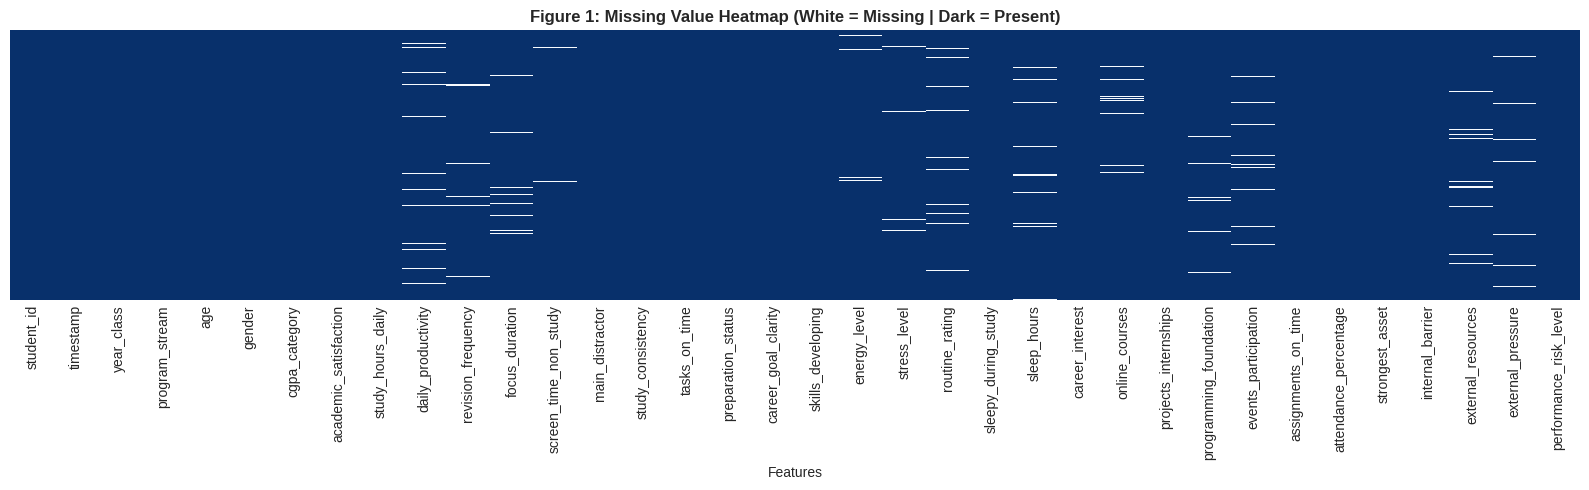

Figure 1 saved


In [34]:
# ── FIGURE 1: Missing Value Heatmap ─────────────────────────────────────────
# White = missing | Dark = present
# Thesis figure: shows data quality before any preprocessing
plt.figure(figsize=(16, 5))
sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=False, cmap='Blues_r')
plt.title('Figure 1: Missing Value Heatmap (White = Missing | Dark = Present)',
          fontsize=12, fontweight='bold')
plt.xlabel('Features')
plt.tight_layout()
plt.savefig('V1_fig1_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

---
## Cell 5 — Target Variable Analysis
We use `program_stream` directly — **no mapping applied**.
The system will recommend a university programme stream.

In [35]:
print('TARGET VARIABLE: program_stream')
print('=' * 60)

target_counts = df_raw[TARGET_COL].value_counts()
target_pct    = df_raw[TARGET_COL].value_counts(normalize=True).mul(100).round(2)

print(pd.DataFrame({'Count': target_counts, 'Percentage %': target_pct}))

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'\nTotal classes:     {df_raw[TARGET_COL].nunique()}')
print(f'Imbalance ratio:   {imbalance_ratio:.2f}:1')

if imbalance_ratio > 10:
    print('\nSevere imbalance detected (ratio greater than 10:1)')
    print('   Models will be biased toward BCA (majority class)')
    print('   Expected: high accuracy but low F1 for minority classes')
    print('   This will be addressed in V3 with stratified sampling (SMOTE)')

TARGET VARIABLE: program_stream
                      Count  Percentage %
program_stream                           
BCA                     696         58.00
BSc Computer Science    129         10.75
BSc IT                   98          8.17
BCom                     87          7.25
BBA                      69          5.75
BSc Cyber Security       68          5.67
BA                       53          4.42

Total classes:     7
Imbalance ratio:   13.13:1

Severe imbalance detected (ratio greater than 10:1)
   Models will be biased toward BCA (majority class)
   Expected: high accuracy but low F1 for minority classes
   This will be addressed in V3 with stratified sampling (SMOTE)


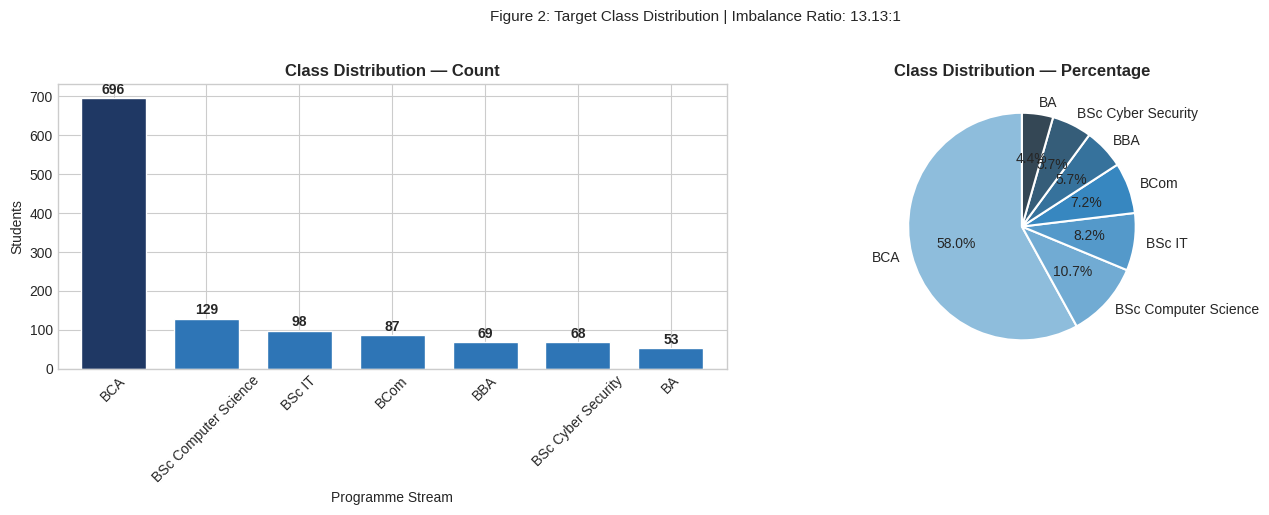

Figure 2 saved


In [36]:
# ── FIGURE 2: Class Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count bar chart
colors = ['#1F3864' if i == 0 else '#2E75B6' for i in range(len(target_counts))]
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.7)
axes[0].set_title('Class Distribution — Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Programme Stream')
axes[0].set_ylabel('Students')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Pie chart
target_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                colors=sns.color_palette('Blues_d', len(target_pct)),
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution — Percentage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle(f'Figure 2: Target Class Distribution | Imbalance Ratio: {imbalance_ratio:.2f}:1',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('V1_fig2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

---
## Cell 6 — Exploratory Data Analysis (EDA)
Understand feature distributions, outliers, and correlations
before any model is trained.

Numeric features: 5


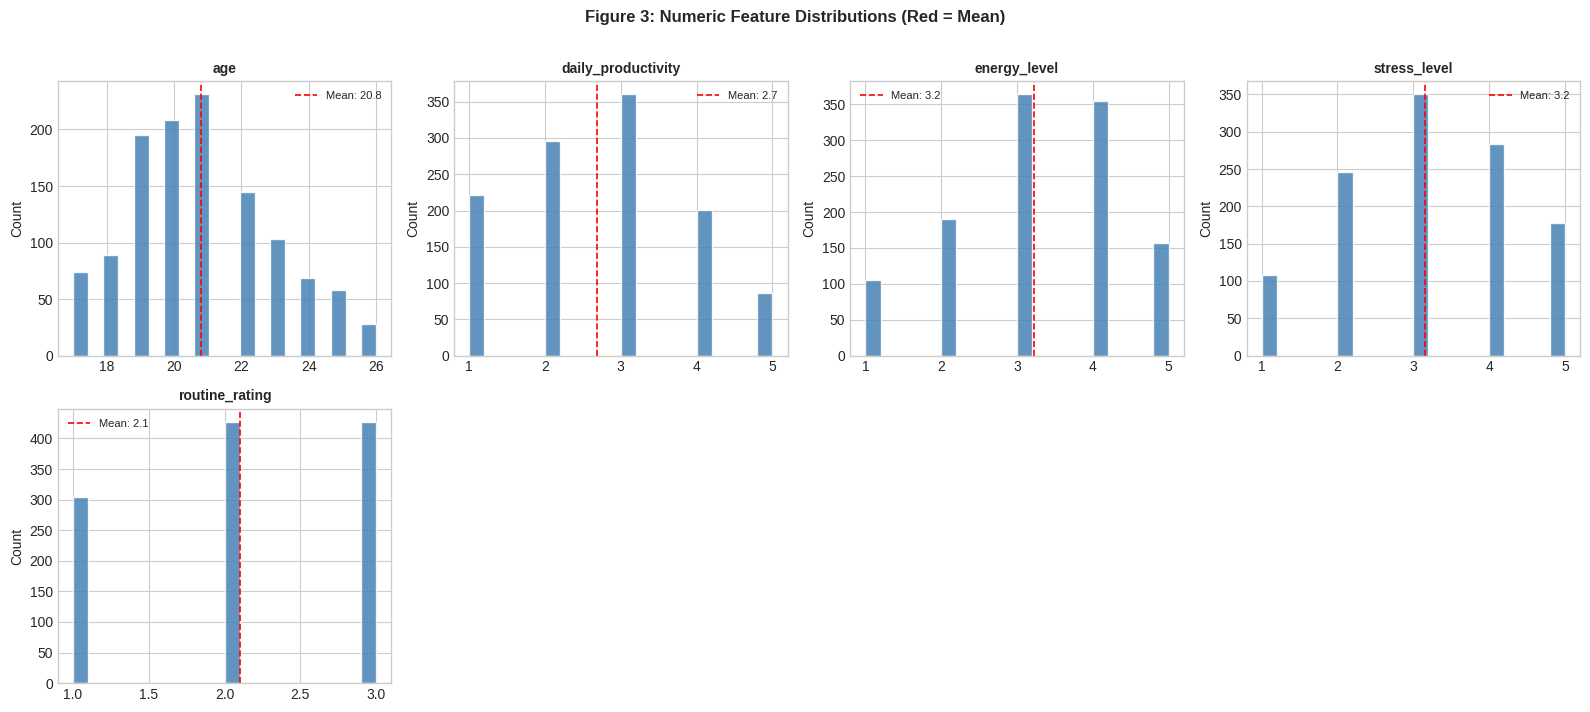

Figure 3 saved


In [37]:
# ── FIGURE 3: Numeric Feature Distributions ─────────────────────────────────
numeric_cols = df_raw.select_dtypes(include='number').columns.tolist()
print(f'Numeric features: {len(numeric_cols)}')

if numeric_cols:
    n_cols = 4
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        axes[idx].hist(df_raw[col].dropna(), bins=20,
                       color='steelblue', edgecolor='white', alpha=0.85)
        axes[idx].set_title(col, fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Count')
        mean_val = df_raw[col].mean()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1.2,
                          label=f'Mean: {mean_val:.1f}')
        axes[idx].legend(fontsize=8)

    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Figure 3: Numeric Feature Distributions (Red = Mean)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('V1_fig3_numeric_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 3 saved')

Categorical features to plot (excluding target): 30


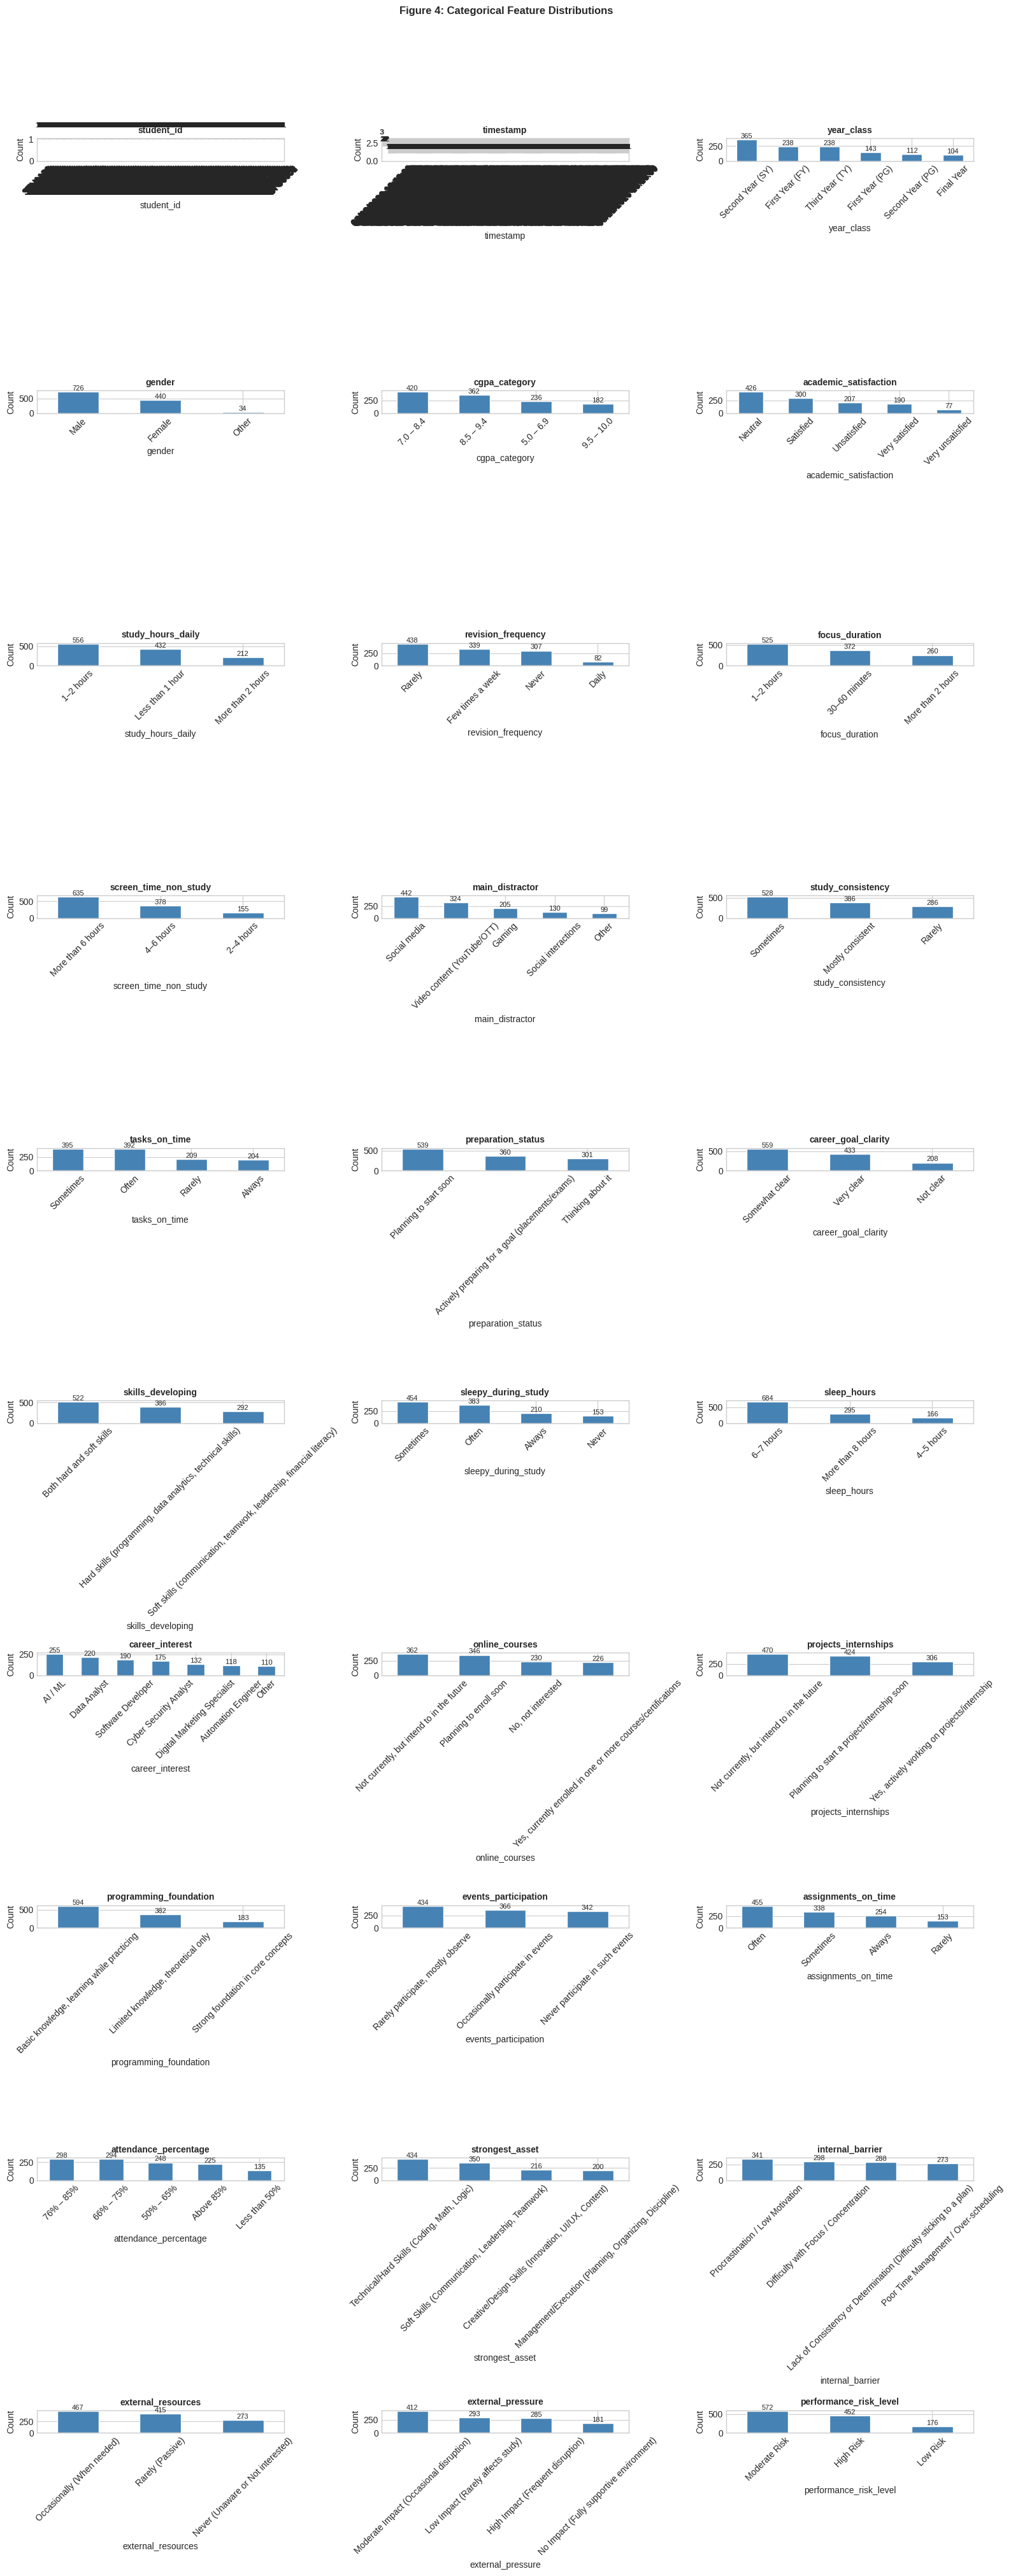

Figure 4 saved


In [38]:
# ── FIGURE 4: Categorical Feature Distributions ──────────────────────────────
cat_cols_plot = [c for c in cat_cols if c != TARGET_COL]
print(f'Categorical features to plot (excluding target): {len(cat_cols_plot)}')

if cat_cols_plot:
    n_cols = 3
    n_rows = (len(cat_cols_plot) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten()

    for idx, col in enumerate(cat_cols_plot):
        counts = df_raw[col].value_counts()
        counts.plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='white')
        axes[idx].set_title(col, fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
        for bar in axes[idx].patches:
            axes[idx].text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + 0.5,
                           str(int(bar.get_height())),
                           ha='center', va='bottom', fontsize=8)

    for idx in range(len(cat_cols_plot), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Figure 4: Categorical Feature Distributions',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('V1_fig4_categorical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 4 saved')

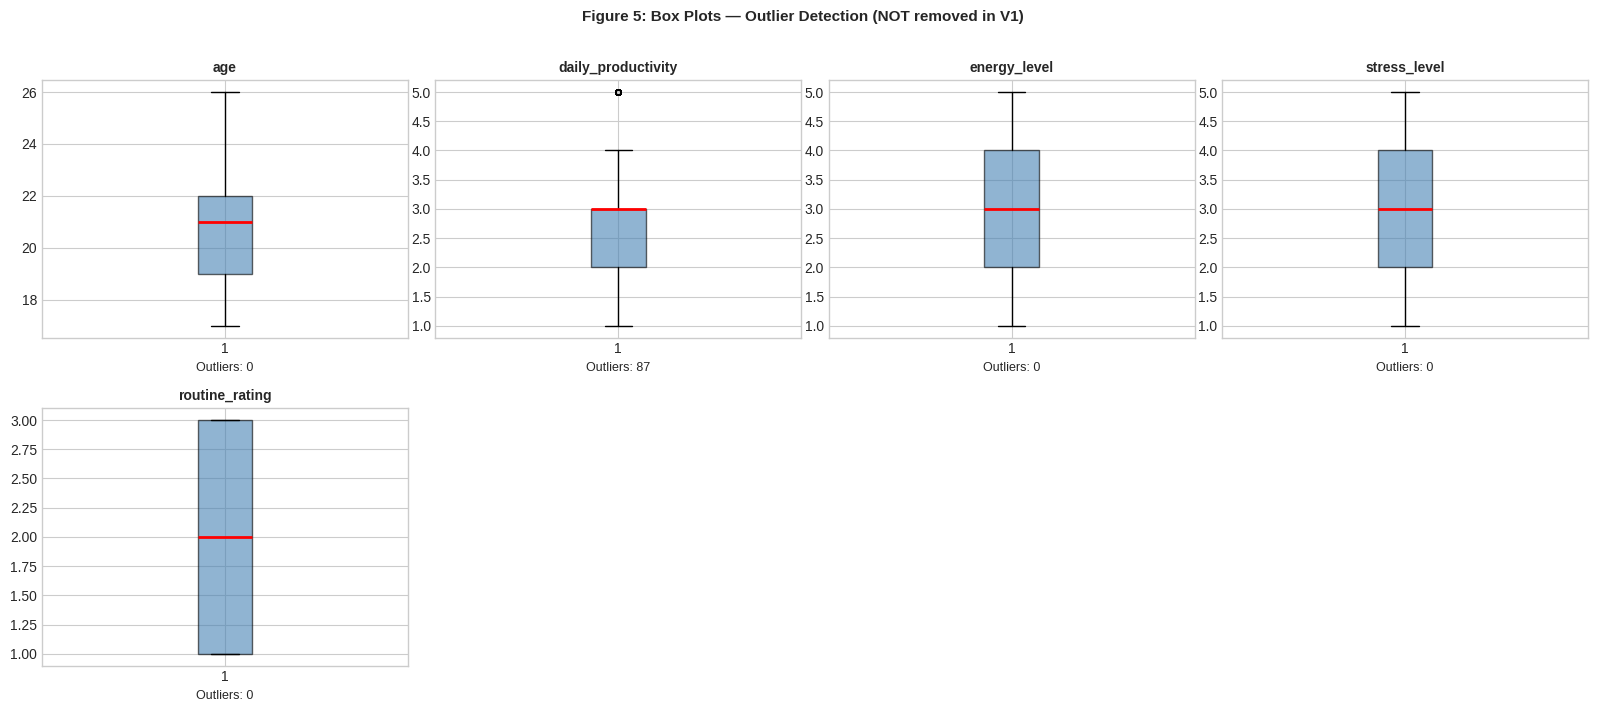

Figure 5 saved


In [39]:
# ── FIGURE 5: Box Plots — Outlier Detection ──────────────────────────────────
# We identify outliers here but do NOT remove them in V1.
if numeric_cols:
    n_cols = 4
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df_raw[col].dropna(), patch_artist=True,
                          boxprops=dict(facecolor='steelblue', alpha=0.6),
                          medianprops=dict(color='red', linewidth=2),
                          flierprops=dict(marker='o', markersize=4, alpha=0.5))
        axes[idx].set_title(col, fontsize=10, fontweight='bold')
        Q1  = df_raw[col].quantile(0.25)
        Q3  = df_raw[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df_raw[col] < Q1 - 1.5*IQR) | (df_raw[col] > Q3 + 1.5*IQR)).sum()
        axes[idx].set_xlabel(f'Outliers: {n_out}', fontsize=9)

    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Figure 5: Box Plots — Outlier Detection (NOT removed in V1)',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('V1_fig5_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 5 saved')

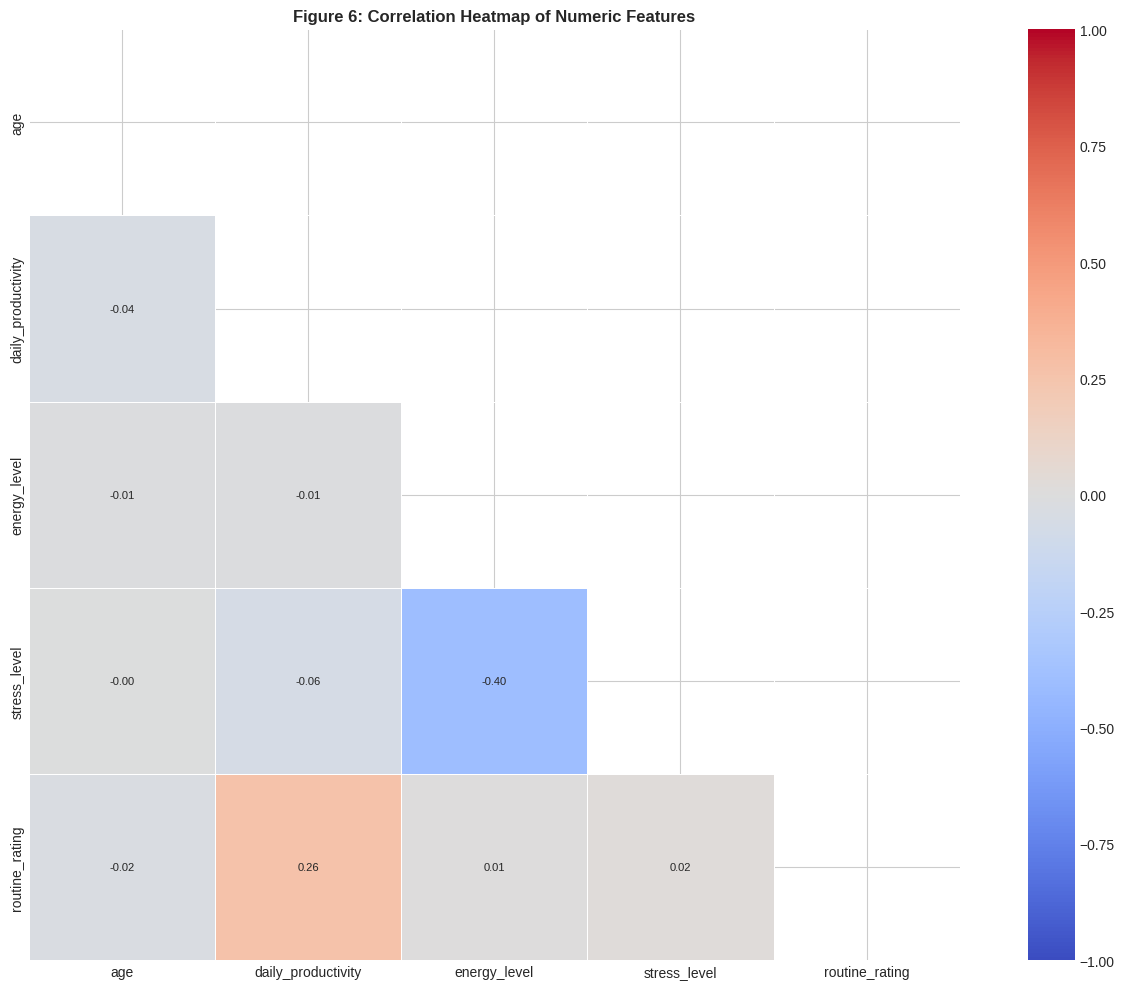

Figure 6 saved

Highly correlated pairs (|r| > 0.7):
   None found above 0.7 threshold


In [40]:
# ── FIGURE 6: Correlation Heatmap ────────────────────────────────────────────
# Pairwise correlation between numeric features.
# High correlation (>0.9) = redundant features.
if len(numeric_cols) > 1:
    corr = df_raw[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, linewidths=0.4,
                annot_kws={'size': 8}, square=True)
    plt.title('Figure 6: Correlation Heatmap of Numeric Features',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('V1_fig6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 6 saved')

    # Report highly correlated pairs
    print('\nHighly correlated pairs (|r| > 0.7):')
    found = False
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            val = corr.iloc[i, j]
            if abs(val) > 0.7:
                print(f'  {corr.columns[i]} ↔ {corr.columns[j]}: {val:.3f}')
                found = True
    if not found:
        print('   None found above 0.7 threshold')

---
## Cell 7 — V1 Minimal Preparation

Only the absolute minimum to make sklearn models run.
**These are technical requirements, not preprocessing decisions:**

| Step | Why it is unavoidable | V2 difference |
|------|----------------------|---------------|
| Drop NaN rows | sklearn crashes on NaN | V2 fills instead of drops |
| Label encode text | sklearn cannot handle text | Same in V2 |
| Separate X and y | required by all models | Same |
| Encode target | sklearn needs integer labels | Same |
| 80/20 split | required to evaluate | Same |

**No scaling. No SMOTE. No imputation.**

In [41]:
# STEP 1: Drop NaN rows
# This is unavoidable -- sklearn will crash if NaN values exist.
# V2 will use imputation instead to preserve all records.
df_v1 = df_raw.dropna().copy()
print(f'Records before dropna: {len(df_raw)}')
print(f'Records after dropna:  {len(df_v1)}')
print(f'Records lost:          {len(df_raw) - len(df_v1)}')
print()

# STEP 2: Remove non-predictive / inappropriate columns
# student_id, timestamp, and year_class are identifiers with no
# generalisable signal -- encoding them lets tree-based models memorise
# training rows directly instead of learning real patterns.
# performance_risk_level is excluded because it is itself a derived label
# from this dataset (a weighted composite of CGPA category, attendance,
# stress level, and academic consistency -- all of which are already
# present as separate features), not a raw student attribute. Using it as
# a predictor for program_stream would give the model indirect access to
# a pre-computed composite score rather than genuine independent signal.
COLS_TO_REMOVE = ['student_id', 'timestamp', 'year_class', 'age', 'performance_risk_level']
removed_present = [c for c in COLS_TO_REMOVE if c in df_v1.columns]
df_v1 = df_v1.drop(columns=removed_present)
print(f'Removed columns: {removed_present}')
print(f'Remaining columns: {df_v1.shape[1]}')
print()

# STEP 3: Train/test split BEFORE any statistic is computed
# The split happens before encoding, so label encoders are fit on the
# training set only -- the test set never contributes to a fitted
# transformation.
X_raw = df_v1.drop(columns=[TARGET_COL])
y_raw = df_v1[TARGET_COL]

X_train_raw, X_test_raw, y_train_labels, y_test_labels = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_raw
)

print(f'Training rows: {len(X_train_raw)}')
print(f'Test rows:     {len(X_test_raw)}')

# STEP 4: Label encode categorical features
# Encoders are fit on TRAINING data only. Any test-set category not seen
# during training is mapped to -1 rather than raising an error, and
# reported below.
label_encoders = {}
unseen_category_report = []

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

cat_cols_to_encode = [c for c in X_train_raw.select_dtypes(include='object').columns]

for col in cat_cols_to_encode:
    le_col = LabelEncoder()
    X_train[col] = le_col.fit_transform(X_train_raw[col].astype(str))
    label_encoders[col] = le_col

    known_categories = set(le_col.classes_)
    test_values = X_test_raw[col].astype(str)
    unseen_mask = ~test_values.isin(known_categories)
    n_unseen = int(unseen_mask.sum())
    if n_unseen > 0:
        unseen_category_report.append({'Column': col, 'Unseen rows': n_unseen})

    encoded_test = np.full(len(test_values), -1, dtype=int)
    encoded_test[~unseen_mask] = le_col.transform(test_values[~unseen_mask])
    X_test[col] = encoded_test

    print(f'Encoded: {col}')

print()
if unseen_category_report:
    print('Categories present in test set but not seen during training:')
    print(pd.DataFrame(unseen_category_report).to_string(index=False))
else:
    print('No unseen test-set categories -- all test categories were present in training')
print()

feature_names = list(X_train.columns)

# STEP 5: Encode target variable
# The target encoder is fit on the training labels only.
le_target = LabelEncoder()
le_target.fit(y_train_labels)
class_names = le_target.classes_

y_train = le_target.transform(y_train_labels)
y_test  = le_target.transform(y_test_labels)

print('Target encoding:')
for name, code in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train_labels == name).sum()
    print(f'  {name:<25} -> {code}  ({count} students in training set)')
print()

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {X_train.shape[1]}')
print('No scaling applied -- V1 uses raw feature values')

# Verify class proportions preserved
print('\nClass proportion check (train vs test should be similar):')
train_dist = pd.Series(y_train).value_counts(normalize=True).round(3)
test_dist  = pd.Series(y_test).value_counts(normalize=True).round(3)
dist_df = pd.concat([train_dist.rename('Train'), test_dist.rename('Test')], axis=1)
dist_df.index = [class_names[i] for i in dist_df.index]
print(dist_df)


Records before dropna: 1200
Records after dropna:  773
Records lost:          427

Removed columns: ['student_id', 'timestamp', 'year_class', 'age', 'performance_risk_level']
Remaining columns: 31

Training rows: 618
Test rows:     155
Encoded: gender
Encoded: cgpa_category
Encoded: academic_satisfaction
Encoded: study_hours_daily
Encoded: revision_frequency
Encoded: focus_duration
Encoded: screen_time_non_study
Encoded: main_distractor
Encoded: study_consistency
Encoded: tasks_on_time
Encoded: preparation_status
Encoded: career_goal_clarity
Encoded: skills_developing
Encoded: sleepy_during_study
Encoded: sleep_hours
Encoded: career_interest
Encoded: online_courses
Encoded: projects_internships
Encoded: programming_foundation
Encoded: events_participation
Encoded: assignments_on_time
Encoded: attendance_percentage
Encoded: strongest_asset
Encoded: internal_barrier
Encoded: external_resources
Encoded: external_pressure

No unseen test-set categories -- all test categories were present i

---
## Cell 8 — Define and Train All 5 Models

Baseline configurations — no hyperparameter tuning in V1.
All models use raw (unscaled) features.

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# DEFINE 5 CLASSIFIERS — BASELINE CONFIGURATIONS
#
# Decision Tree:  No depth limit → expected to overfit (H3)
# Random Forest:  100 trees → expected best performer (H1)
# SVM:            RBF kernel, no scaling → may underperform vs V2 scaled
# KNN:            k=5 default, no scaling → distance affected by raw ranges
# Naive Bayes:    Probabilistic baseline, assumes feature independence
# ─────────────────────────────────────────────────────────────────────────────
models = {
    'Decision Tree':  DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':  RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM':            SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'KNN':            KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':    GaussianNB(),
}

# 5-fold stratified CV — preserves class proportions in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Five classifiers defined (baseline, no tuning):')
for name in models:
    print(f'  {name} defined')

Five classifiers defined (baseline, no tuning):
  Decision Tree defined
  Random Forest defined
  SVM defined
  KNN defined
  Naive Bayes defined


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN AND EVALUATE ALL 5 MODELS
#
# 6 metrics per model:
#   1. Accuracy          — overall correctness (headline number)
#   2. Precision macro   — correctness of positive predictions (all classes equal)
#   3. Recall macro      — coverage of actual class members (all classes equal)
#   4. F1 macro          — harmonic mean of precision and recall (PRIMARY METRIC)
#   5. CV mean ± std     — stability across 5 folds
#   6. Train-Test gap    — overfitting diagnostic (gap > 15% = overfit)
#
# macro averaging treats all 7 classes equally regardless of size.
# This is important because BCA (696 samples) should not dominate the score.
# ─────────────────────────────────────────────────────────────────────────────
v1_results = []

print('Training all 5 models on V1 (raw data, no preprocessing)...')
print('=' * 70)

for model_name, model in models.items():
    print(f'\nTraining model: {model_name}')

    # Train on raw unscaled features
    model.fit(X_train, y_train)

    # Predict on test and train
    y_pred       = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # Compute metrics
    acc      = accuracy_score(y_test, y_pred)
    prec     = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec      = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_test  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_train = f1_score(y_train, y_train_pred, average='macro', zero_division=0)
    gap      = f1_train - f1_test

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1_macro', n_jobs=-1)

    # Overfitting diagnosis
    if gap > 0.15:
        diagnosis = 'OVERFIT'
    elif f1_test < 0.50 and f1_train < 0.50:
        diagnosis = 'UNDERFIT'
    else:
        diagnosis = 'GOOD FIT'

    v1_results.append({
        'Model':          model_name,
        'Accuracy':       round(acc,            4),
        'Precision':      round(prec,           4),
        'Recall':         round(rec,            4),
        'F1 Test':        round(f1_test,        4),
        'F1 Train':       round(f1_train,       4),
        'Train-Test Gap': round(gap,            4),
        'CV Mean':        round(cv_scores.mean(),4),
        'CV Std':         round(cv_scores.std(), 4),
        'Diagnosis':      diagnosis,
    })

    print(f'  Accuracy:        {acc:.4f}')
    print(f'  F1 Test:         {f1_test:.4f}   |   F1 Train: {f1_train:.4f}')
    print(f'  Train-Test Gap:  {gap:.4f}   →   {diagnosis}')
    print(f'  CV Mean ± Std:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n' + '=' * 70)
print('All 5 models trained and evaluated')

Training all 5 models on V1 (raw data, no preprocessing)...

Training model: Decision Tree
  Accuracy:        0.3742
  F1 Test:         0.1710   |   F1 Train: 1.0000
  Train-Test Gap:  0.8290   →   OVERFIT
  CV Mean ± Std:   0.1599 ± 0.0292

Training model: Random Forest
  Accuracy:        0.5871
  F1 Test:         0.1061   |   F1 Train: 1.0000
  Train-Test Gap:  0.8939   →   OVERFIT
  CV Mean ± Std:   0.1056 ± 0.0005

Training model: SVM
  Accuracy:        0.5871
  F1 Test:         0.1057   |   F1 Train: 0.1055
  Train-Test Gap:  -0.0002   →   UNDERFIT
  CV Mean ± Std:   0.1055 ± 0.0003

Training model: KNN
  Accuracy:        0.5613
  F1 Test:         0.1597   |   F1 Train: 0.2731
  Train-Test Gap:  0.1134   →   UNDERFIT
  CV Mean ± Std:   0.1345 ± 0.0098

Training model: Naive Bayes
  Accuracy:        0.5742
  F1 Test:         0.1409   |   F1 Train: 0.2191
  Train-Test Gap:  0.0782   →   UNDERFIT
  CV Mean ± Std:   0.1162 ± 0.0102

All 5 models trained and evaluated


---
## Cell 9 — Results Table and Visualisation

In [44]:
# ── TABLE 1: Full Results Comparison ─────────────────────────────────────────
v1_results_df     = pd.DataFrame(v1_results)
v1_results_sorted = v1_results_df.sort_values('F1 Test', ascending=False)

print('TABLE 1: V1 Model Comparison (Original Dataset — No Preprocessing)')
print('Sorted by F1 Test Score (Primary Metric)')
print('=' * 100)
print(v1_results_sorted.to_string(index=False))

best_model_name_v1 = v1_results_sorted.iloc[0]['Model']
best_f1_v1         = v1_results_sorted.iloc[0]['F1 Test']

print(f'\nBest V1 model: {best_model_name_v1}  (F1 Test = {best_f1_v1:.4f})')

v1_results_df.to_csv('V1_table1_model_comparison.csv', index=False)
print('Saved: V1_table1_model_comparison.csv')

TABLE 1: V1 Model Comparison (Original Dataset — No Preprocessing)
Sorted by F1 Test Score (Primary Metric)
        Model  Accuracy  Precision  Recall  F1 Test  F1 Train  Train-Test Gap  CV Mean  CV Std Diagnosis
Decision Tree    0.3742     0.1686  0.1768   0.1710    1.0000          0.8290   0.1599  0.0292   OVERFIT
          KNN    0.5613     0.1712  0.1719   0.1597    0.2731          0.1134   0.1345  0.0098  UNDERFIT
  Naive Bayes    0.5742     0.2583  0.1571   0.1409    0.2191          0.0782   0.1162  0.0102  UNDERFIT
Random Forest    0.5871     0.0844  0.1429   0.1061    1.0000          0.8939   0.1056  0.0005   OVERFIT
          SVM    0.5871     0.0839  0.1429   0.1057    0.1055         -0.0002   0.1055  0.0003  UNDERFIT

Best V1 model: Decision Tree  (F1 Test = 0.1710)
Saved: V1_table1_model_comparison.csv


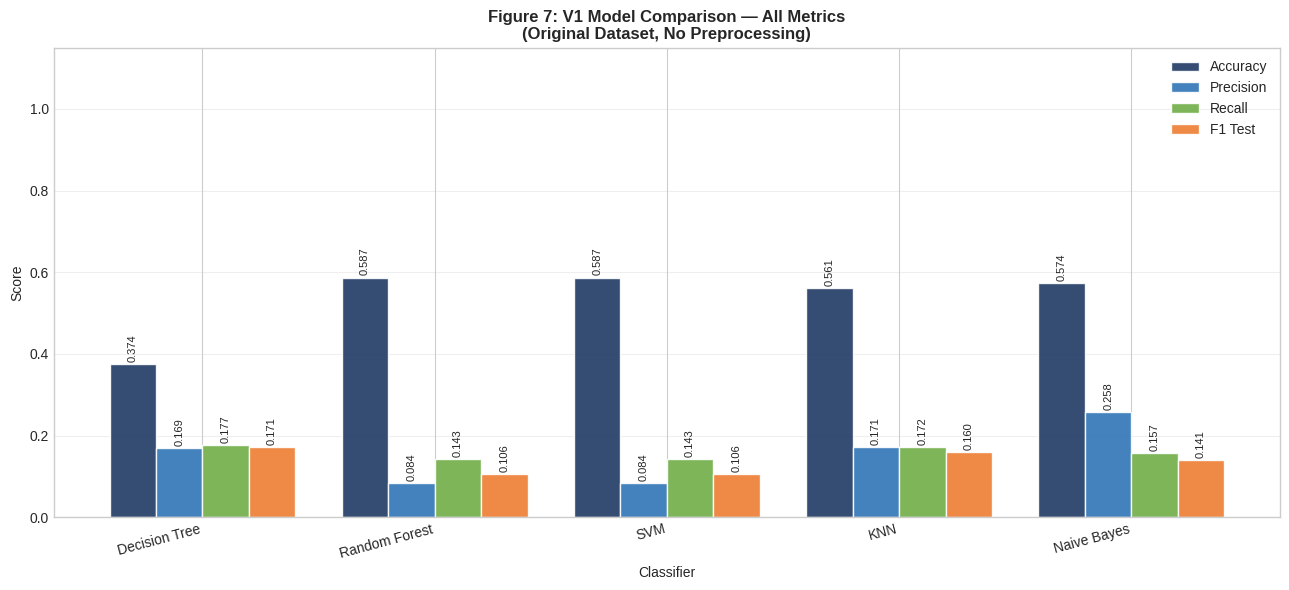

Figure 7 saved


In [45]:
# ── FIGURE 7: Model Comparison Bar Chart ─────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Test']
x      = np.arange(len(v1_results_df))
width  = 0.2
colors = ['#1F3864', '#2E75B6', '#70AD47', '#ED7D31']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i*width, v1_results_df[metric], width,
                  label=metric, color=color, edgecolor='white', alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=8, rotation=90)

ax.set_xlabel('Classifier')
ax.set_ylabel('Score')
ax.set_title('Figure 7: V1 Model Comparison — All Metrics\n(Original Dataset, No Preprocessing)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(v1_results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('V1_fig7_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 7 saved')

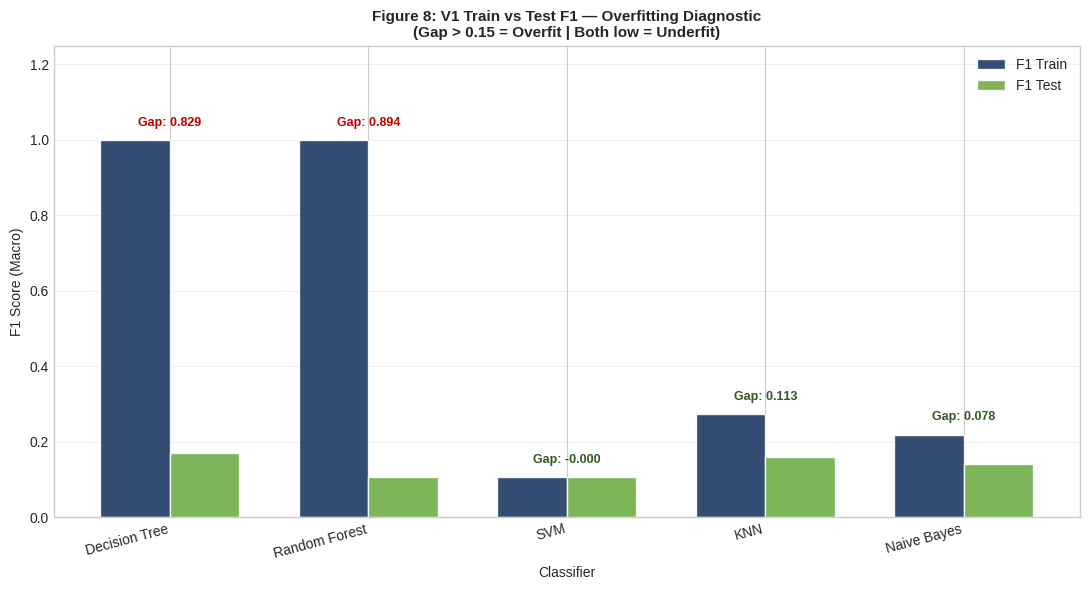

Figure 8 saved


In [46]:
# ── FIGURE 8: Train vs Test F1 — Overfitting Diagnostic ──────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(v1_results_df))
w = 0.35

ax.bar(x - w/2, v1_results_df['F1 Train'], w, label='F1 Train',
       color='#1F3864', edgecolor='white', alpha=0.9)
ax.bar(x + w/2, v1_results_df['F1 Test'],  w, label='F1 Test',
       color='#70AD47', edgecolor='white', alpha=0.9)

for i, (train, test, gap) in enumerate(zip(
        v1_results_df['F1 Train'],
        v1_results_df['F1 Test'],
        v1_results_df['Train-Test Gap'])):
    color = '#C00000' if gap > 0.15 else '#375623'
    ax.annotate(f'Gap: {gap:.3f}',
                xy=(i, max(train, test) + 0.03),
                ha='center', va='bottom',
                fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Classifier')
ax.set_ylabel('F1 Score (Macro)')
ax.set_title('Figure 8: V1 Train vs Test F1 — Overfitting Diagnostic\n'
             '(Gap > 0.15 = Overfit | Both low = Underfit)',
             fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(v1_results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.25)
ax.legend()
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('V1_fig8_overfitting_diagnostic.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 8 saved')

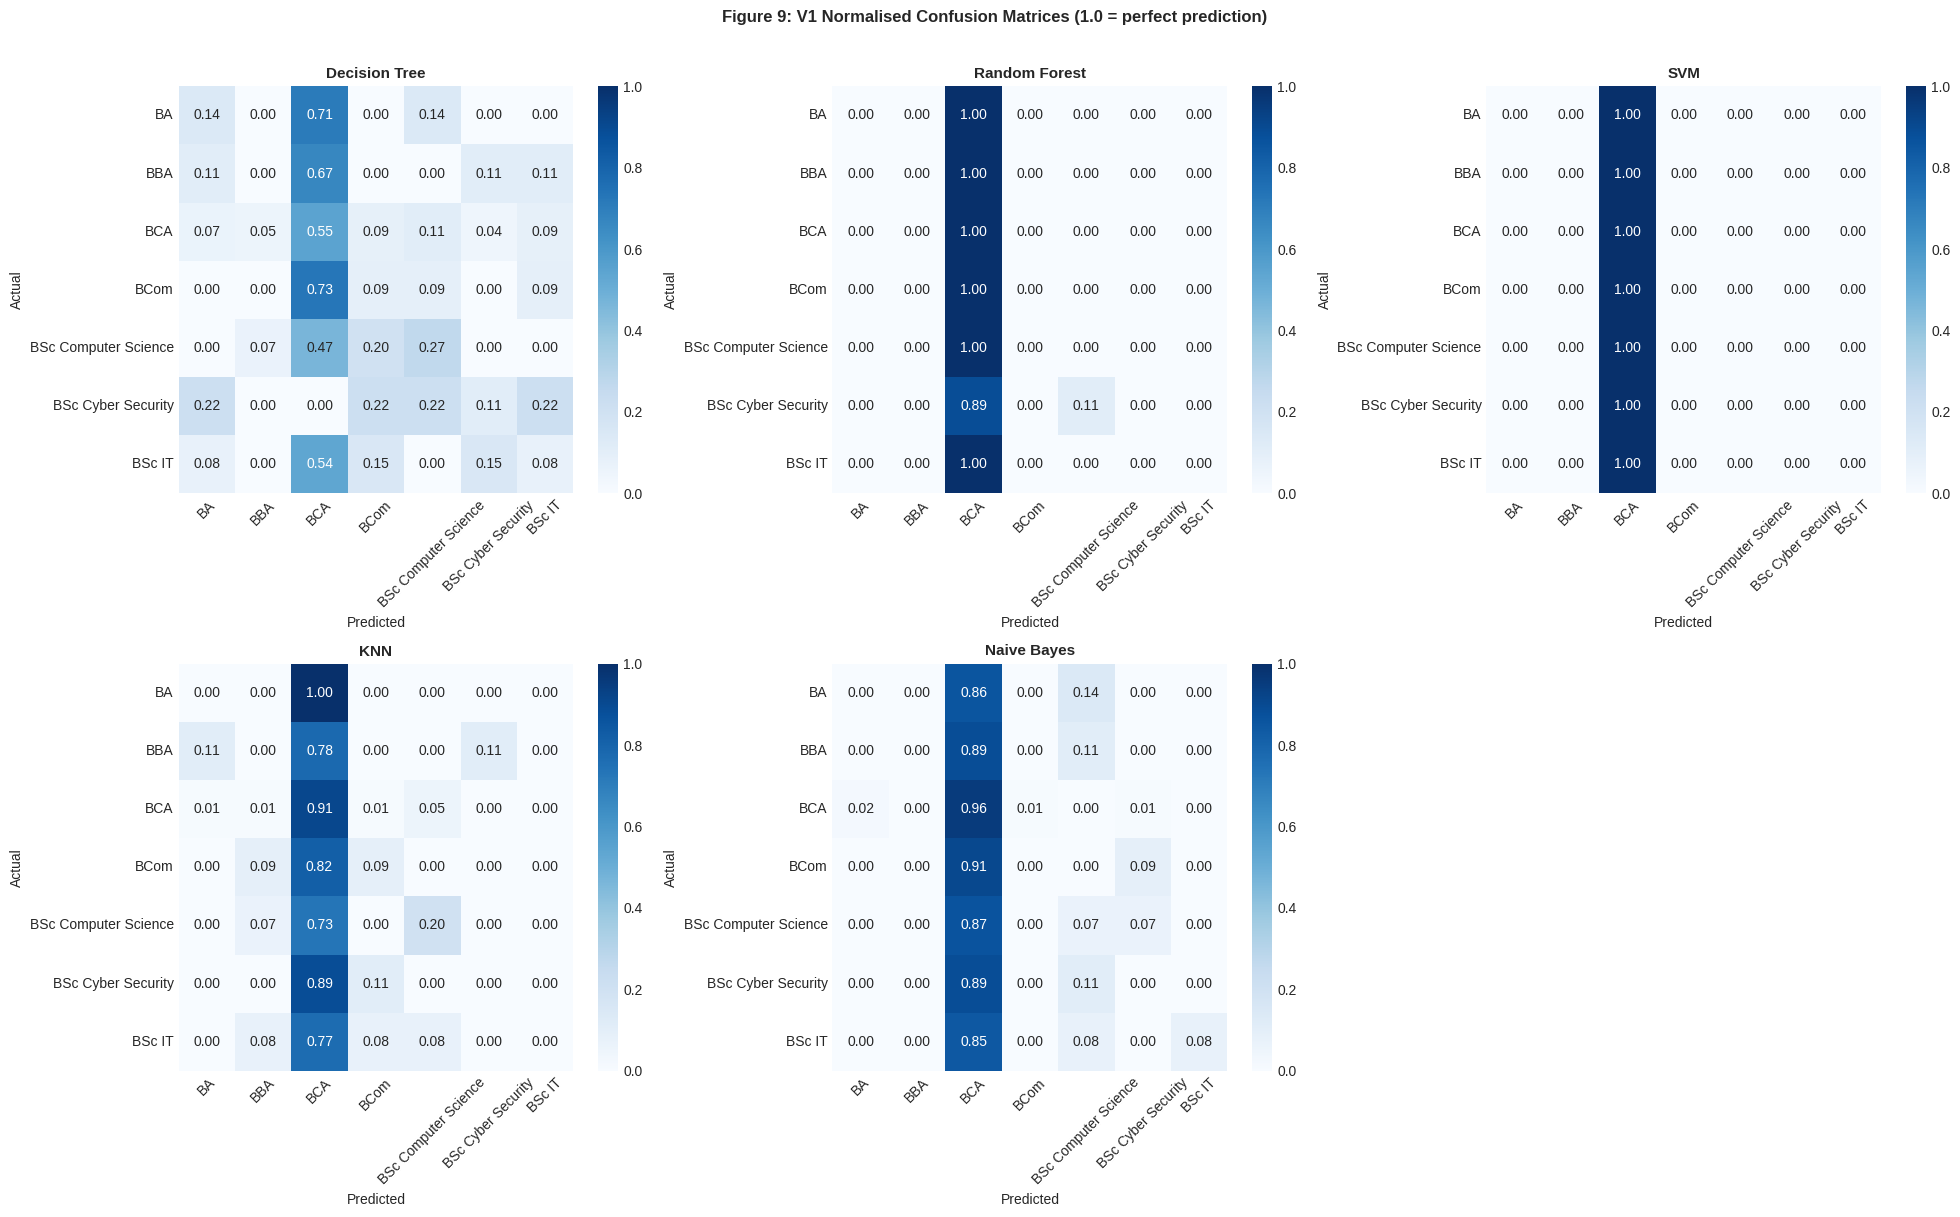

Figure 9 saved


In [47]:
# ── FIGURE 9: Normalised Confusion Matrices — All 5 Models ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, ax=axes[idx], annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1)
    axes[idx].set_title(model_name, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].tick_params(axis='x', rotation=45)

axes[5].set_visible(False)
plt.suptitle('Figure 9: V1 Normalised Confusion Matrices (1.0 = perfect prediction)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('V1_fig9_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 9 saved')

In [48]:
# ── Detailed classification report for V1 best model ─────────────────────────
best_model_v1 = models[best_model_name_v1]
y_pred_best   = best_model_v1.predict(X_test)

print(f'DETAILED CLASSIFICATION REPORT — {best_model_name_v1}')
print('=' * 70)
print(classification_report(y_test, y_pred_best,
                             target_names=class_names, zero_division=0))
print('Note: Minority classes (BA, BSc Cyber Security) expected to show')
print('lower F1 due to 13.13:1 imbalance — addressed in V3 with SMOTE.')

DETAILED CLASSIFICATION REPORT — Decision Tree
                      precision    recall  f1-score   support

                  BA       0.09      0.14      0.11         7
                 BBA       0.00      0.00      0.00         9
                 BCA       0.60      0.55      0.57        91
                BCom       0.06      0.09      0.07        11
BSc Computer Science       0.22      0.27      0.24        15
  BSc Cyber Security       0.12      0.11      0.12         9
              BSc IT       0.08      0.08      0.08        13

            accuracy                           0.37       155
           macro avg       0.17      0.18      0.17       155
        weighted avg       0.40      0.37      0.38       155

Note: Minority classes (BA, BSc Cyber Security) expected to show
lower F1 due to 13.13:1 imbalance — addressed in V3 with SMOTE.


---
## Cell 10 — SHAP Explainability (V1 Best Model)

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# SHAP — applied to V1 best model
# TreeExplainer for RF/DT (fast, exact)
# KernelExplainer for SVM/KNN/NB (slower, approximate)
# ─────────────────────────────────────────────────────────────────────────────
print(f'Applying SHAP to: {best_model_name_v1}')

if best_model_name_v1 in ['Decision Tree', 'Random Forest']:
    explainer   = shap.TreeExplainer(best_model_v1)
    shap_values = explainer.shap_values(X_test.values)
    print('TreeExplainer used')
else:
    background  = shap.sample(X_train.values, 100, random_state=RANDOM_STATE)
    explainer   = shap.KernelExplainer(best_model_v1.predict_proba, background)
    shap_values = explainer.shap_values(X_test.values[:100])
    print('KernelExplainer used (sample of 100 for speed)')

print(f'SHAP values shape: {np.array(shap_values).shape}')

Applying SHAP to: Decision Tree
TreeExplainer used
SHAP values shape: (155, 30, 7)


Raw SHAP values shape: (155, 30, 7)
Type: 3D array (155, 30, 7)
Importance array shape after reduction: (30,)
Expected: (30,)  — one value per feature


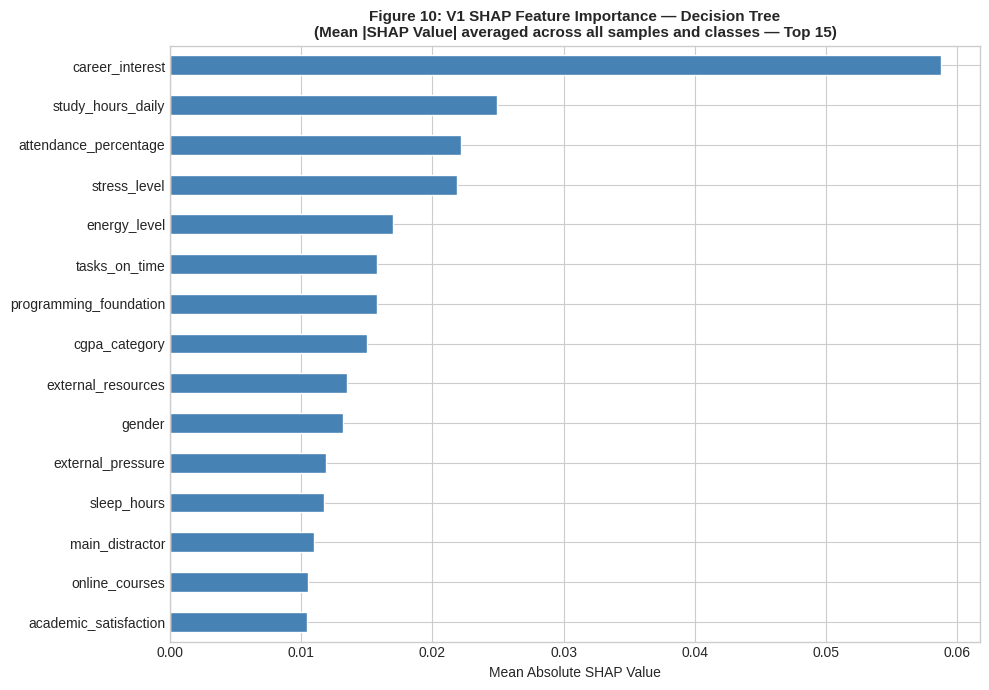

Figure 10 saved


In [50]:
# ── FIGURE 10: SHAP Global Feature Importance ────────────────────────────────
#
# shap_values can have different shapes depending on model type:
#   - Tree multi-class RF:  list of arrays, each shape (n_samples, n_features)
#   - Single output:        array of shape (n_samples, n_features)
#   - 3D array:             shape (n_samples, n_features, n_classes)
#
# Goal: get one importance score per feature → shape must be (n_features,)
# We take mean absolute SHAP across all samples AND all classes.
# ─────────────────────────────────────────────────────────────────────────────

shap_arr = np.array(shap_values)   # convert to numpy for shape inspection
print(f'Raw SHAP values shape: {shap_arr.shape}')

# Case 1: list of arrays — one array per class (most common for RF multi-class)
# shap_values = [array(n_samples, n_features), array(n_samples, n_features), ...]
if isinstance(shap_values, list):
    # Stack into 3D: (n_classes, n_samples, n_features)
    # Take abs → mean over samples (axis=1) → mean over classes (axis=0)
    importance_per_feature = np.mean(
        [np.abs(sv).mean(axis=0) for sv in shap_values], axis=0
    )
    print(f'Type: list of {len(shap_values)} class arrays')

# Case 2: 3D array — shape (n_samples, n_features, n_classes)
elif shap_arr.ndim == 3:
    # abs → mean over samples (axis=0) → mean over classes (axis=-1)
    importance_per_feature = np.abs(shap_arr).mean(axis=0).mean(axis=-1)
    print(f'Type: 3D array {shap_arr.shape}')

# Case 3: 2D array — shape (n_samples, n_features) — single output or binary
elif shap_arr.ndim == 2:
    importance_per_feature = np.abs(shap_arr).mean(axis=0)
    print(f'Type: 2D array {shap_arr.shape}')

else:
    importance_per_feature = np.abs(shap_arr).mean(axis=0)
    print(f'Type: other shape {shap_arr.shape}')

print(f'Importance array shape after reduction: {importance_per_feature.shape}')
print(f'Expected: ({len(feature_names)},)  — one value per feature')

# Build Series — one importance score per feature
shap_importance = pd.Series(
    importance_per_feature,
    index=feature_names
).sort_values(ascending=True)

# Plot top 15 features
plt.figure(figsize=(10, 7))
shap_importance.tail(15).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Figure 10: V1 SHAP Feature Importance — {best_model_name_v1}\n'
          '(Mean |SHAP Value| averaged across all samples and classes — Top 15)',
          fontsize=11, fontweight='bold')
plt.xlabel('Mean Absolute SHAP Value')
plt.tight_layout()
plt.savefig('V1_fig10_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 10 saved')

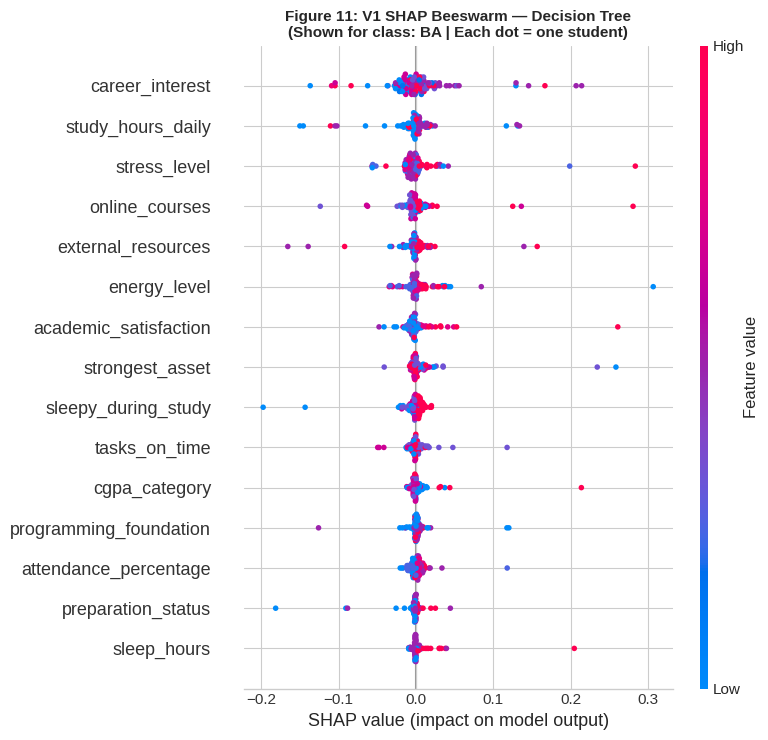

Figure 11 saved


In [51]:
 # ── FIGURE 11: SHAP Beeswarm Plot ────────────────────────────────────────────
# For multi-class RF, shap_values is a list — we pick one class to display.
# We show the class with the most samples (BCA = index of majority class).
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 8))

if isinstance(shap_values, list):
    # Pick the majority class index to display (BCA is likely index 0)
    # Find which class has the most test samples
    majority_class_idx = np.bincount(y_test).argmax()
    shap_for_plot = shap_values[majority_class_idx]
    class_label   = class_names[majority_class_idx]
    print(f'Showing beeswarm for class: {class_label} (majority class)')
elif shap_arr.ndim == 3:
    # 3D array: pick first class slice
    shap_for_plot = shap_arr[:, :, 0]
    class_label   = class_names[0]
else:
    shap_for_plot = shap_values
    class_label   = 'all'

shap.summary_plot(
    shap_for_plot[:100], # Apply slicing to shap_for_plot as well
    X_test.values[:100], # Modified to use only the first 100 samples of X_test
    feature_names=feature_names,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title(f'Figure 11: V1 SHAP Beeswarm — {best_model_name_v1}\n'
          f'(Shown for class: {class_label} | Each dot = one student)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('V1_fig11_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 11 saved')

---
## Cell 11 — V1 Summary and Save Artefacts

In [52]:
print('=' * 70)
print('V1 SUMMARY — Original Dataset, No Preprocessing')
print('=' * 70)
print(f'Records used:       {len(df_v1)} (after dropna from {len(df_raw)})')
print(f'Columns removed:    {removed_present}')
print(f'Features:           {X_train.shape[1]}')
print(f'Target classes:     {len(class_names)} — {list(class_names)}')
print(f'Imbalance ratio:    {imbalance_ratio:.2f}:1')
print(f'Scaling:            None')
print(f'Imputation:         None')
print(f'SMOTE:              None')
print()
print('Model Results (sorted by F1 Test):')
print(v1_results_sorted[['Model','Accuracy','F1 Test','Train-Test Gap','Diagnosis']].to_string(index=False))
print(f'\nBest V1 model: {best_model_name_v1} (F1 = {best_f1_v1:.4f})')
print()
print('Figures saved:')
for f in ['V1_fig1_missing_values.png','V1_fig2_class_distribution.png',
          'V1_fig3_numeric_distributions.png','V1_fig4_categorical_distributions.png',
          'V1_fig5_boxplots.png','V1_fig6_correlation_heatmap.png',
          'V1_fig7_model_comparison.png','V1_fig8_overfitting_diagnostic.png',
          'V1_fig9_confusion_matrices.png','V1_fig10_shap_importance.png',
          'V1_fig11_shap_beeswarm.png']:
    print(f'  Saved: {f}')
print('\nTable saved: V1_table1_model_comparison.csv')
print('\n→ Next: Run V2 notebook (imputation + scaling) and compare results.')

V1 SUMMARY — Original Dataset, No Preprocessing
Records used:       773 (after dropna from 1200)
Columns removed:    ['student_id', 'timestamp', 'year_class', 'age', 'performance_risk_level']
Features:           30
Target classes:     7 — ['BA', 'BBA', 'BCA', 'BCom', 'BSc Computer Science', 'BSc Cyber Security', 'BSc IT']
Imbalance ratio:    13.13:1
Scaling:            None
Imputation:         None
SMOTE:              None

Model Results (sorted by F1 Test):
        Model  Accuracy  F1 Test  Train-Test Gap Diagnosis
Decision Tree    0.3742   0.1710          0.8290   OVERFIT
          KNN    0.5613   0.1597          0.1134  UNDERFIT
  Naive Bayes    0.5742   0.1409          0.0782  UNDERFIT
Random Forest    0.5871   0.1061          0.8939   OVERFIT
          SVM    0.5871   0.1057         -0.0002  UNDERFIT

Best V1 model: Decision Tree (F1 = 0.1710)

Figures saved:
  Saved: V1_fig1_missing_values.png
  Saved: V1_fig2_class_distribution.png
  Saved: V1_fig3_numeric_distributions.png
  Sa

In [53]:
# Save artefacts for cross-version comparison
SAVE_PATH = '/content/drive/MyDrive/Thesis/'

joblib.dump(best_model_v1,  SAVE_PATH + 'V1_best_model.pkl')
joblib.dump(le_target,      SAVE_PATH + 'V1_label_encoder.pkl')
joblib.dump(label_encoders, SAVE_PATH + 'V1_feature_encoders.pkl')

with open(SAVE_PATH + 'V1_feature_names.json', 'w') as f:
    json.dump(feature_names, f)
with open(SAVE_PATH + 'V1_class_names.json', 'w') as f:
    json.dump(list(class_names), f)

v1_results_df.to_csv(SAVE_PATH + 'V1_results.csv', index=False)

print('All V1 artefacts saved to Google Drive')
print('   Use V1_results.csv in the cross-version comparison notebook')

All V1 artefacts saved to Google Drive
   Use V1_results.csv in the cross-version comparison notebook
